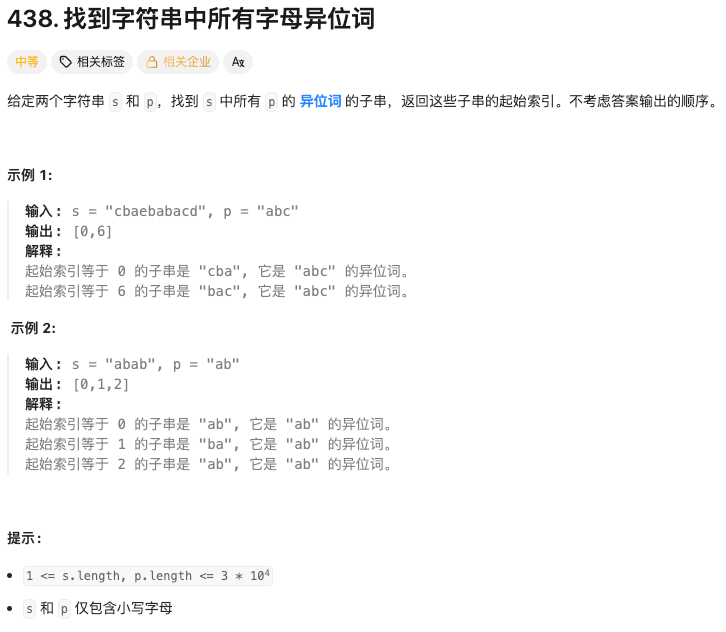

- 用质数代表每一个字母，乘积为key。dict = [key:[start1,start2,...]]

In [6]:
from typing import List


class Solution:
    def findAnagrams(self, s: str, p: str) -> List[int]:
        if len(p) > len(s):
            return []
        value = [2,3,5,7,11,13,17,19,23,29,
               31,37,41,43,47,53,59,61,67,71,
               73,79,83,89,97,101]
        letters = 'abcdefghijklmnopqrstuvwxyz'
        let_val = {}
        middle_res = {}
        for i in range(26):
            let_val[letters[i]] = value[i]

        target_key = 1
        for i in range(len(p)):
            target_key = target_key * let_val[p[i]]

        position = 0
        while position<=len(s)-len(p):
            current_key = 1
            current_position = position
            for i in range(len(p)):
                current_key = current_key * let_val[s[current_position]]
                current_position += 1
            if current_key == target_key:
                if current_key in middle_res:
                    middle_res[current_key].append(position)
                else:
                    middle_res[current_key] = [position]
            position += 1

        if target_key in middle_res:
            res = middle_res[target_key]
        else:
            res = []
        return res

if __name__ == '__main__':
    s = 'bb'
    p = 'aa'
    print(Solution().findAnagrams(s, p))

20001 10000


In [35]:
from typing import List


class Solution:
    def findAnagrams(self, s: str, p: str) -> List[int]:
        left = 0 # 左指针
        right = left + len(p) - 1 # 右指针
        dict_p = {}
        res = []
        for c in p:
            dict_p[c] = dict_p.get(c, 0) + 1

        dict_s = {}
        while right <= len(s) - 1:
            current_position = left
            for i in range(len(p)):
                dict_s[s[current_position]] = dict_s.get(s[current_position], 0) + 1
                if s[current_position] in dict_p and dict_s[s[current_position]] > dict_p[s[current_position]]:
                    break
                if s[current_position] not in dict_p:
                    break
                current_position += 1
            same = True
            if len(dict_p) == len(dict_s):
                for key in dict_s:
                    if key in dict_p:
                        if dict_s[key] != dict_p[key]:
                            same = False
                            break
                    else:
                        same = False
                if same:
                    res.append(left)
            left += 1
            right = left + len(p) - 1
            dict_s = {}
        return res

if __name__ == '__main__':
    s = "abab"
    p = 'ab'
    print(Solution().findAnagrams(s, p))

[0, 1, 2]


In [42]:
from typing import List


class Solution:
    def findAnagrams(self, s: str, p: str) -> List[int]:
        left = 0 # 左指针
        right = left + len(p) - 1 # 右指针
        dict_p = {}
        res = []
        dict_s = {}
        for c in p:
            dict_p[c] = dict_p.get(c, 0) + 1
        for i in range(len(p)):
            dict_s[s[left+i]] = dict_s.get(s[left+i], 0) + 1

        while right < len(s):
            same = True
            # 判断是否是异构词
            if len(dict_p) == len(dict_s):
                for key in dict_s :
                    if key in dict_p:
                        if dict_s[key] != dict_p[key]:
                            same = False
                            break
                    else:
                        same = False
                if same:
                    res.append(left)
            # 窗口移动，重新更新dict_s
            dict_s[s[left]] -= 1
            if dict_s[s[left]] == 0:
                del dict_s[s[left]]
            left += 1
            right += 1
            if right < len(s):
                dict_s[s[right]] = dict_s.get(s[right], 0) + 1
            else :
                break
        return res

if __name__ == '__main__':
    s = "cbaebabacd"
    p = 'abc'
    print(Solution().findAnagrams(s, p))

[0, 6]
